In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

DATA_PATH = Path("../data/raw/ETTh1.csv")

In [2]:
df = pd.read_csv(DATA_PATH, parse_dates=["date"])
print(f"Shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")
print(f"Date range: {df['date'].min()} → {df['date'].max()}")
df.head()

Shape: (17420, 8)
Columns: ['date', 'HUFL', 'HULL', 'MUFL', 'MULL', 'LUFL', 'LULL', 'OT']
Date range: 2016-07-01 00:00:00 → 2018-06-26 19:00:00


,date,HUFL,HULL,MUFL,MULL,LUFL,LULL,OT
0,2016-07-01 00:00:00,5.827,2.009,1.599,0.462,4.203,1.340,30.531000
1,2016-07-01 01:00:00,5.693,2.076,1.492,0.426,4.142,1.371,27.787001
2,2016-07-01 02:00:00,5.157,1.741,1.279,0.355,3.777,1.218,27.787001
3,2016-07-01 03:00:00,5.090,1.942,1.279,0.391,3.807,1.279,25.044001
4,2016-07-01 04:00:00,5.358,1.942,1.492,0.462,3.868,1.279,21.948000


In [3]:
print("Missing values per column:")
print(df.isna().sum())
print("\nDtypes:")
print(df.dtypes)
print("\nStats for OT:")
print(df["OT"].describe())

Missing values per column:
date    0
HUFL    0
HULL    0
MUFL    0
MULL    0
LUFL    0
LULL    0
OT      0
dtype: int64

Dtypes:
date    datetime64[us]
HUFL           float64
HULL           float64
MUFL           float64
MULL           float64
LUFL           float64
LULL           float64
OT             float64
dtype: object

Stats for OT:
count    17420.000000
mean        13.324672
std          8.566946
min         -4.080000
25%          6.964000
50%         11.396000
75%         18.079000
max         46.007000
Name: OT, dtype: float64


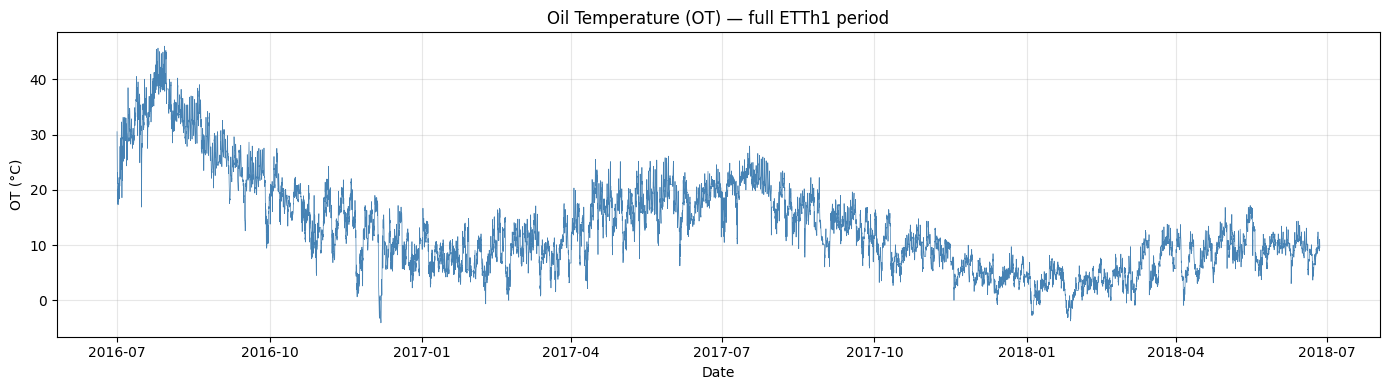

In [4]:
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(df["date"], df["OT"], linewidth=0.5, color="steelblue")
ax.set_title("Oil Temperature (OT) — full ETTh1 period")
ax.set_xlabel("Date")
ax.set_ylabel("OT (°C)")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [5]:
# Convention papers Informer / Autoformer / etc.
# 12 months train / 4 months val / 4 months test, in hours
TRAIN_HOURS = 12 * 30 * 24   # 8640
VAL_HOURS   = 4 * 30 * 24    # 2880
TEST_HOURS  = 4 * 30 * 24    # 2880

train_end = TRAIN_HOURS
val_end   = TRAIN_HOURS + VAL_HOURS
test_end  = TRAIN_HOURS + VAL_HOURS + TEST_HOURS

print(f"Train: rows [0:{train_end}]       → {df.iloc[0]['date']} → {df.iloc[train_end-1]['date']}")
print(f"Val:   rows [{train_end}:{val_end}]  → {df.iloc[train_end]['date']} → {df.iloc[val_end-1]['date']}")
print(f"Test:  rows [{val_end}:{test_end}]  → {df.iloc[val_end]['date']} → {df.iloc[test_end-1]['date']}")
print(f"\nTotal used: {test_end} / {len(df)} rows")

Train: rows [0:8640]       → 2016-07-01 00:00:00 → 2017-06-25 23:00:00
Val:   rows [8640:11520]  → 2017-06-26 00:00:00 → 2017-10-23 23:00:00
Test:  rows [11520:14400]  → 2017-10-24 00:00:00 → 2018-02-20 23:00:00

Total used: 14400 / 17420 rows


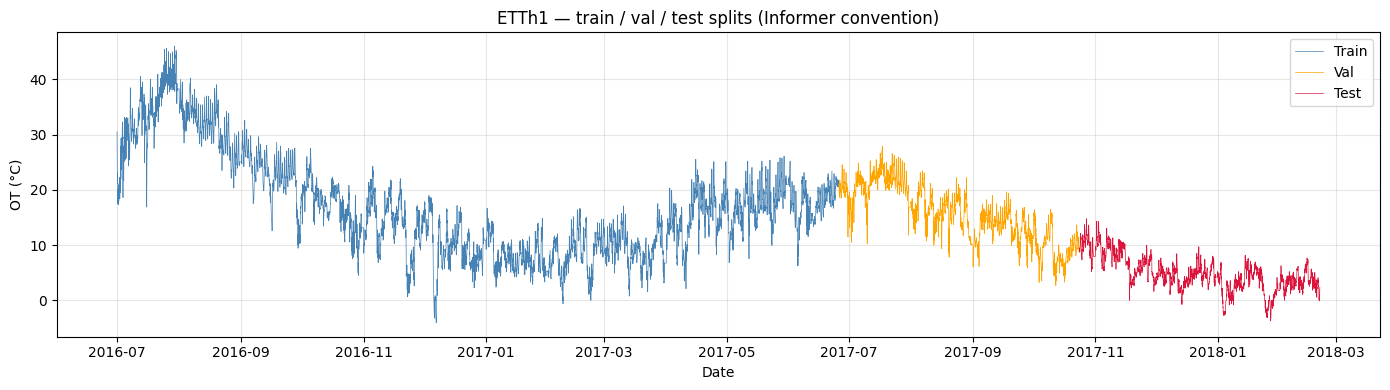

In [6]:
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(df["date"][:train_end], df["OT"][:train_end], linewidth=0.5, label="Train", color="steelblue")
ax.plot(df["date"][train_end:val_end], df["OT"][train_end:val_end], linewidth=0.5, label="Val", color="orange")
ax.plot(df["date"][val_end:test_end], df["OT"][val_end:test_end], linewidth=0.5, label="Test", color="crimson")
ax.set_title("ETTh1 — train / val / test splits (Informer convention)")
ax.set_xlabel("Date")
ax.set_ylabel("OT (°C)")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [7]:
import sys
sys.path.append("..")

from src.data import build_dataloaders

train_loader, val_loader, test_loader, scaler = build_dataloaders(
    csv_path="../data/raw/ETTh1.csv",
    lookback=192,
    horizon=96,
    batch_size=64,
)

print(f"Train batches: {len(train_loader)}")
print(f"Val batches:   {len(val_loader)}")
print(f"Test batches:  {len(test_loader)}")
print(f"Scaler mean: {scaler.mean.flatten()}, std: {scaler.std.flatten()}")

x, y = next(iter(train_loader))
print(f"\nBatch input shape:  {x.shape}    # expected (64, 192, 1)")
print(f"Batch target shape: {y.shape}    # expected (64, 96)")
print(f"Input dtype: {x.dtype}, Target dtype: {y.dtype}")

Train batches: 130
Val batches:   41
Test batches:  41
Scaler mean: [17.128262], std: [9.176491]

Batch input shape:  torch.Size([64, 192, 1])    # expected (64, 192, 1)
Batch target shape: torch.Size([64, 96])    # expected (64, 96)
Input dtype: torch.float32, Target dtype: torch.float32


In [8]:
from src.model import LSTMForecaster
from src.utils import load_config

cfg = load_config("../configs/config.yaml")

model = LSTMForecaster(
    input_size=cfg["model"]["input_size"],
    hidden_size=cfg["model"]["hidden_size"],
    num_layers=cfg["model"]["num_layers"],
    horizon=cfg["data"]["horizon"],
    dropout=cfg["model"]["dropout"],
)

print(model)
print(f"\nTotal params: {sum(p.numel() for p in model.parameters()):,}")

# Forward pass test
x, y = next(iter(train_loader))
y_pred = model(x)
print(f"\nInput shape:      {x.shape}    # (64, 192, 1)")
print(f"Prediction shape: {y_pred.shape}  # (64, 96)")
print(f"Target shape:     {y.shape}    # (64, 96)")

LSTMForecaster(
  (lstm): LSTM(1, 128, num_layers=2, batch_first=True, dropout=0.2)
  (head): Linear(in_features=128, out_features=96, bias=True)
)

Total params: 211,552

Input shape:      torch.Size([64, 192, 1])    # (64, 192, 1)
Prediction shape: torch.Size([64, 96])  # (64, 96)
Target shape:     torch.Size([64, 96])    # (64, 96)
